# Diagnostic de Défauts — Moteur CC 12V (Données Réelles)
# Classification Binaire : Normal vs Surcharge

---

**Dataset** : 6 fichiers CSV acquis manuellement sur un moteur CC 12V réel via ESP32

**Capteurs** : Tension (V) | Courant (A) | Vitesse (RPM)

**Approche** : Fenêtres glissantes → Features statistiques → Classification ML

**Cible** : Déploiement sur ESP32 — export du modèle en code C via m2cgen

---

## Table des matières

1. Contexte et inventaire du dataset
2. Installation des dépendances
3. Chargement et nettoyage des données
4. Analyse exploratoire (EDA)
5. Segmentation en fenêtres glissantes
6. Extraction des caractéristiques (Feature Engineering)
7. Préparation des données
8. Entraînement et évaluation des modèles
9. Analyse des résultats
10. Exportation du modèle pour ESP32

---
## 1. Contexte et inventaire du dataset

### 1.1 Provenance des données

Ce dataset a été acquis **manuellement** sur un vrai moteur à courant continu 12V
instrumenté avec un microcontrôleur ESP32. Les valeurs sont transmises via port série
(PuTTY) à une cadence de **2 Hz** (500 ms) ou **10 Hz** (100 ms).

### 1.2 Inventaire des 6 fichiers

| Fichier | Label | Tension | Courant | Vitesse | Fréq. | Lignes utiles |
|---------|-------|:-------:|:-------:|:-------:|------:|------:|
| `dataset_moteur.csv` | **Normal** | ✓ | ✗ | ✗ | 10 Hz | ~3 574 |
| `dataset_finale_eet_5A.csv` | **Normal** | ✓ | ✓ | ✓ | 2 Hz | ~843 |
| `dataset_trés_finale_30A.csv` | **Normal** | ✓ | ✓ | ✓ | 2 Hz | ~708 |
| `dataset_surcharge.csv` | **Surcharge** | ✓ | ✗ | ✗ | 10 Hz | ~3 689 |
| `dataset_surcharge_5A.csv` | **Surcharge** | ✓ | ✓ | ✗ | 2 Hz | ~740 |
| `dataset_surcharge_30AA.csv` | **Surcharge** | ✓ | ✓ | ✗ | 2 Hz | ~572 |

### 1.3 Problèmes identifiés et corrections appliquées

| # | Problème | Fichiers | Correction |
|---|----------|----------|------------|
| 1 | En-tête PuTTY (13 lignes de boot ESP32) | `surcharge_5A`, `surcharge_30A` | Skip jusqu'à la ligne contenant `Temps` |
| 2 | Séparateur décimal virgule `,` | `moteur`, `surcharge` | `decimal=','` |
| 3 | Virgule parasite dans `Tension(V),` | `moteur` | `rstrip(',')` sur les noms de colonnes |
| 4 | Lignes moteur éteint (Tension = 0 V) | Tous | Suppression si `Tension < 1 V` |
| 5 | Pic de courant aberrant 13.51 A | `surcharge_5A` | Suppression si `Courant > 5 A` |
| 6 | Ligne NaN de fin de fichier | `surcharge_30A` | `dropna()` |
| 7 | Capteurs absents selon le fichier | Voir tableau | Imputation à **0** (valeur neutre) |

### 1.4 Stratégie de segmentation

Les enregistrements longs (3–7 min) sont découpés en fenêtres glissantes :
- **Taille** : 30 échantillons | **Stride** : 15 (50 % recouvrement)
- **Résultat** : ~700 fenêtres indépendantes → cross-validation 5 plis classique

---
## 2. Installation des dépendances

In [1]:
# Décommenter si exécution dans Google Colab :
%pip install xgboost m2cgen scikit-learn imbalanced-learn pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


---
## 3. Chargement et nettoyage des données

### 3.1 Configuration des fichiers

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from pathlib import Path
warnings.filterwarnings("ignore")

# ================================================================
# CONFIGURATION — adapter le chemin si nécessaire
# ================================================================
DATA_DIR = Path.cwd()
if not (DATA_DIR / "dataset_moteur (1).csv").exists():
    DATA_DIR = DATA_DIR / "dataset jloud"

def find_csv(*patterns):
    for pattern in patterns:
        matches = sorted(DATA_DIR.glob(pattern))
        if matches:
            return matches[0].name
    raise FileNotFoundError(f"Aucun CSV trouvé dans {DATA_DIR} pour: {patterns}")

FILES_CONFIG = {
    # clé : (nom_fichier, label, décimal, skip_putty)
    "moteur":        (find_csv("dataset_moteur*.csv"),              "Normal",    ",", False),
    "finale_5A":     (find_csv("dataset finale eet 5A*.csv"),       "Normal",    ".", False),
    "finale_30A":    (find_csv("dataset*finale 30A.csv"),           "Normal",    ".", False),
    "surcharge":     (find_csv("dataset surcharge*.csv", "dataset_surcharge*.csv"), "Surcharge", ",", False),
    "surcharge_5A":  (find_csv("dataset surcharge 5A*.csv"),        "Surcharge", ".", True),
    "surcharge_30A": (find_csv("dataset surcharge 30AA*.csv"),      "Surcharge", ".", True),
}

SENSORS      = ["Tension(V)", "Courant(A)", "Vitesse(RPM)"]
LABEL_TO_INT = {"Normal": 0, "Surcharge": 1}
COLORS       = {"Normal": "#2196F3", "Surcharge": "#FF5722"}

### 3.2 Fonction de chargement unifiée

In [3]:
def load_and_clean(file_path, label, decimal=".", skip_putty=False):
    """
    Charge un fichier CSV, applique toutes les corrections identifiées,
    et retourne un DataFrame propre avec les 3 colonnes de capteurs.
    """
    # ── Lecture brute ──────────────────────────────────────────────
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    # ── Correction 1 : suppression de l'en-tête PuTTY ─────────────
    if skip_putty:
        start = next(i for i, l in enumerate(lines) if "Temps" in l)
        lines = lines[start:]

    df = pd.read_csv(StringIO("".join(lines)), sep=";", decimal=decimal)

    # ── Correction 2 : virgule parasite dans les noms de colonnes ──
    df.columns = [c.strip().rstrip(",") for c in df.columns]

    # ── Correction 2b : conversion robuste des colonnes numériques ─
    numeric_cols = ["Temps(ms)", "Tension(V)", "Courant(A)", "Vitesse(RPM)"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.strip().str.replace(",", ".", regex=False),
                errors="coerce"
            )

    # ── Correction 3 : suppression des lignes invalides ────────────
    df = df.dropna(subset=["Temps(ms)", "Tension(V)"])  # lignes invalides
    df = df[df["Tension(V)"] >= 1.0]          # moteur éteint
    if "Courant(A)" in df.columns:
        df = df[df["Courant(A)"] <= 5.0]      # pic aberrant 13.51 A

    # ── Correction 4 : ajout des capteurs manquants (imputation 0) ─
    for col in ["Courant(A)", "Vitesse(RPM)"]:
        if col not in df.columns:
            df[col] = 0.0

    # ── Mise en forme finale ────────────────────────────────────────
    df = df[["Temps(ms)"] + SENSORS].copy()
    df["Label"]  = label
    df["Source"] = Path(file_path).stem
    return df.reset_index(drop=True)


# ── Chargement de tous les fichiers ──────────────────────────────
print("=" * 65)
print("CHARGEMENT ET NETTOYAGE DES DONNÉES")
print("=" * 65)

all_dfs = {}
for name, (filename, label, decimal, skip_putty) in FILES_CONFIG.items():
    path = Path(DATA_DIR) / filename
    df   = load_and_clean(path, label, decimal, skip_putty)
    all_dfs[name] = df
    ic = "✓" if df["Courant(A)"].std() > 0   else "✗ imputé=0"
    iv = "✓" if df["Vitesse(RPM)"].std() > 0 else "✗ imputé=0"
    print(f"  {name:<18} [{label:<10}]  {len(df):>5} pts | "
          f"Tension ✓ | Courant {ic} | Vitesse {iv}")

total = sum(len(d) for d in all_dfs.values())
print(f"\n  Total lignes nettoyées : {total}")
print(f"  Normal    : {sum(len(d) for d in all_dfs.values() if d['Label'].iloc[0]=='Normal')}")
print(f"  Surcharge : {sum(len(d) for d in all_dfs.values() if d['Label'].iloc[0]=='Surcharge')}") 

CHARGEMENT ET NETTOYAGE DES DONNÉES
  moteur             [Normal    ]   3574 pts | Tension ✓ | Courant ✗ imputé=0 | Vitesse ✗ imputé=0
  finale_5A          [Normal    ]    843 pts | Tension ✓ | Courant ✓ | Vitesse ✓
  finale_30A         [Normal    ]    708 pts | Tension ✓ | Courant ✓ | Vitesse ✓
  surcharge          [Surcharge ]   3689 pts | Tension ✓ | Courant ✗ imputé=0 | Vitesse ✗ imputé=0
  surcharge_5A       [Surcharge ]    740 pts | Tension ✓ | Courant ✓ | Vitesse ✗ imputé=0
  surcharge_30A      [Surcharge ]    572 pts | Tension ✓ | Courant ✓ | Vitesse ✗ imputé=0

  Total lignes nettoyées : 10126
  Normal    : 5125
  Surcharge : 5001


### 3.3 Vérification statistique après nettoyage

In [4]:
print(f"\n{'Fichier':<18} {'Label':<12} {'N':>5}  "
      f"{'Tension moy':>11}  {'Courant moy':>12}  {'Vitesse moy':>12}")
print("-" * 72)
for name, df in all_dfs.items():
    print(f"  {name:<16} {df['Label'].iloc[0]:<12} {len(df):>5}  "
          f"  {df['Tension(V)'].mean():>7.2f} V"
          f"   {df['Courant(A)'].mean():>7.3f} A"
          f"   {df['Vitesse(RPM)'].mean():>7.1f} RPM")


Fichier            Label            N  Tension moy   Courant moy   Vitesse moy
------------------------------------------------------------------------
  moteur           Normal        3574       9.51 V     0.000 A       0.0 RPM
  finale_5A        Normal         843      10.17 V     1.235 A     280.7 RPM
  finale_30A       Normal         708      10.26 V     0.045 A     270.1 RPM
  surcharge        Surcharge     3689       9.50 V     0.000 A       0.0 RPM
  surcharge_5A     Surcharge      740       9.85 V     1.223 A       0.0 RPM
  surcharge_30A    Surcharge      572       9.93 V     0.164 A       0.0 RPM


---
## 4. Analyse exploratoire des données

### 4.1 Signaux temporels bruts

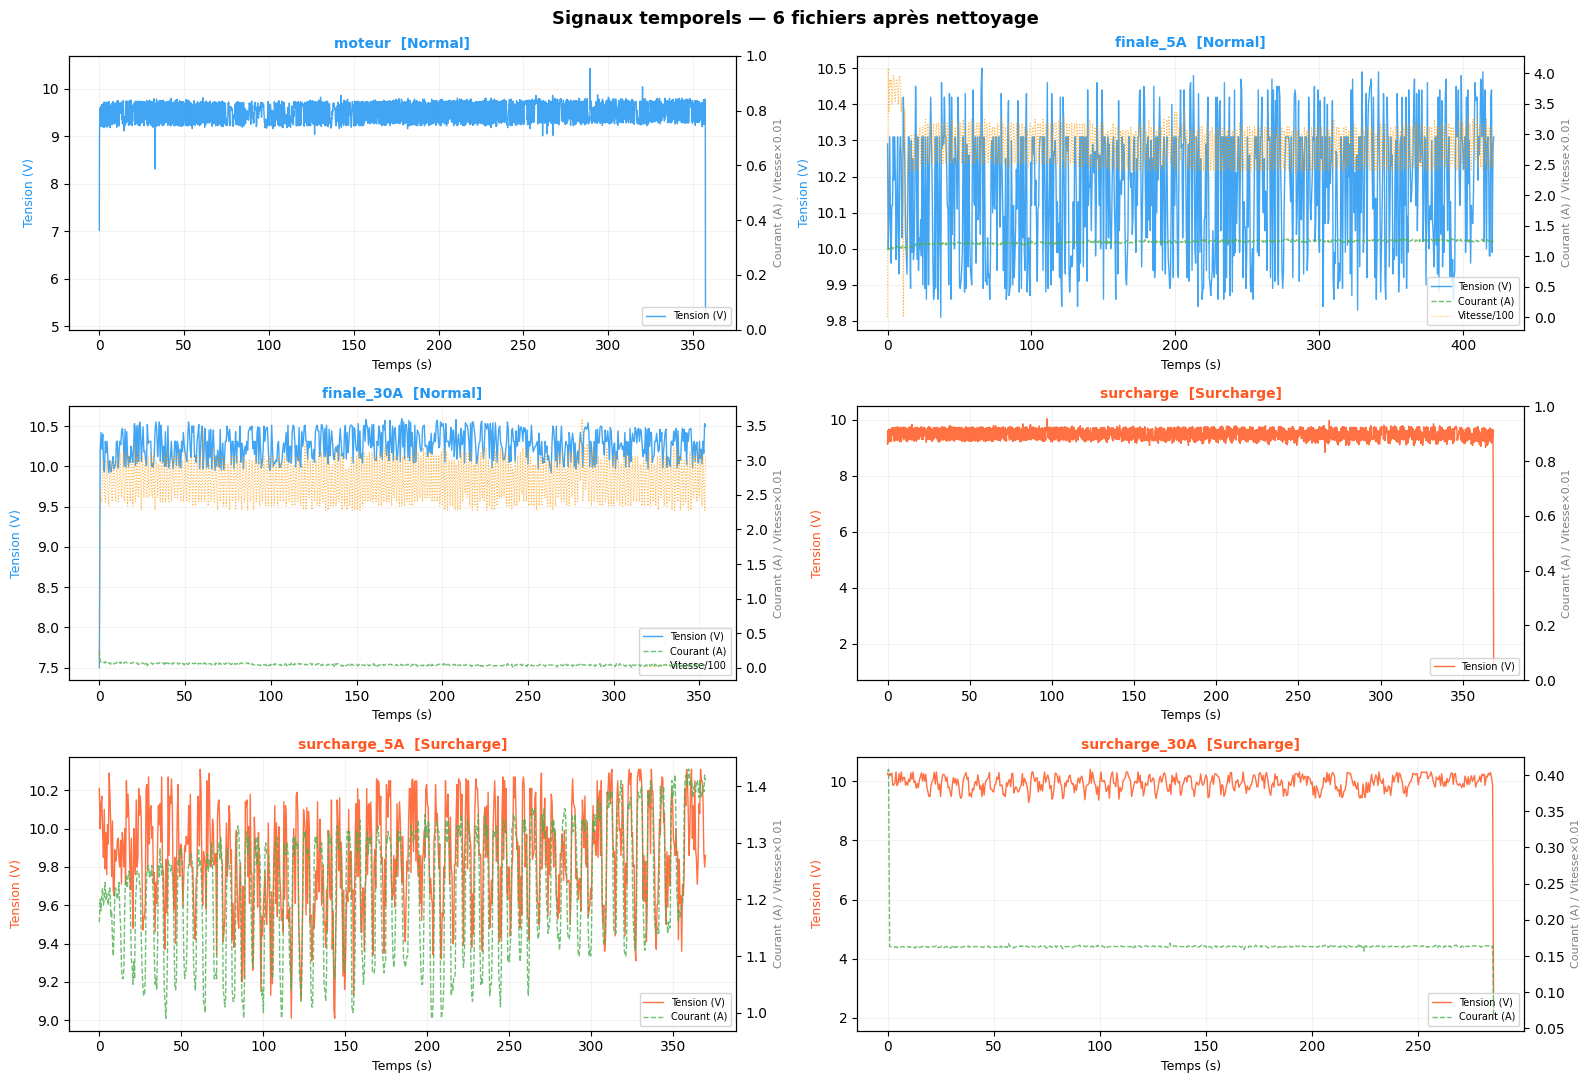

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
axes_flat = axes.flatten()

for idx, (name, df) in enumerate(all_dfs.items()):
    ax   = axes_flat[idx]
    ax2  = ax.twinx()
    lbl  = df["Label"].iloc[0]
    col  = COLORS[lbl]
    t    = df["Temps(ms)"].values / 1000

    ax.plot(t, df["Tension(V)"], color=col, lw=1, alpha=0.85,
            label="Tension (V)")

    lines2, labs2 = [], []
    if df["Courant(A)"].std() > 0:
        l, = ax2.plot(t, df["Courant(A)"], color="#4CAF50", lw=1,
                      alpha=0.8, linestyle="--")
        lines2.append(l); labs2.append("Courant (A)")
    if df["Vitesse(RPM)"].std() > 0:
        l, = ax2.plot(t, df["Vitesse(RPM)"] / 100, color="#FF9800",
                      lw=0.8, alpha=0.7, linestyle=":")
        lines2.append(l); labs2.append("Vitesse/100")

    ax.set_title(f"{name}  [{lbl}]", fontsize=10, fontweight="bold", color=col)
    ax.set_xlabel("Temps (s)", fontsize=9)
    ax.set_ylabel("Tension (V)", color=col, fontsize=9)
    ax2.set_ylabel("Courant (A) / Vitesse×0.01", fontsize=8, color="grey")
    ax.grid(True, alpha=0.15)

    h1, l1 = ax.get_legend_handles_labels()
    ax.legend(h1 + lines2, l1 + labs2, loc="lower right", fontsize=7)

plt.suptitle("Signaux temporels — 6 fichiers après nettoyage",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Distributions des capteurs par classe

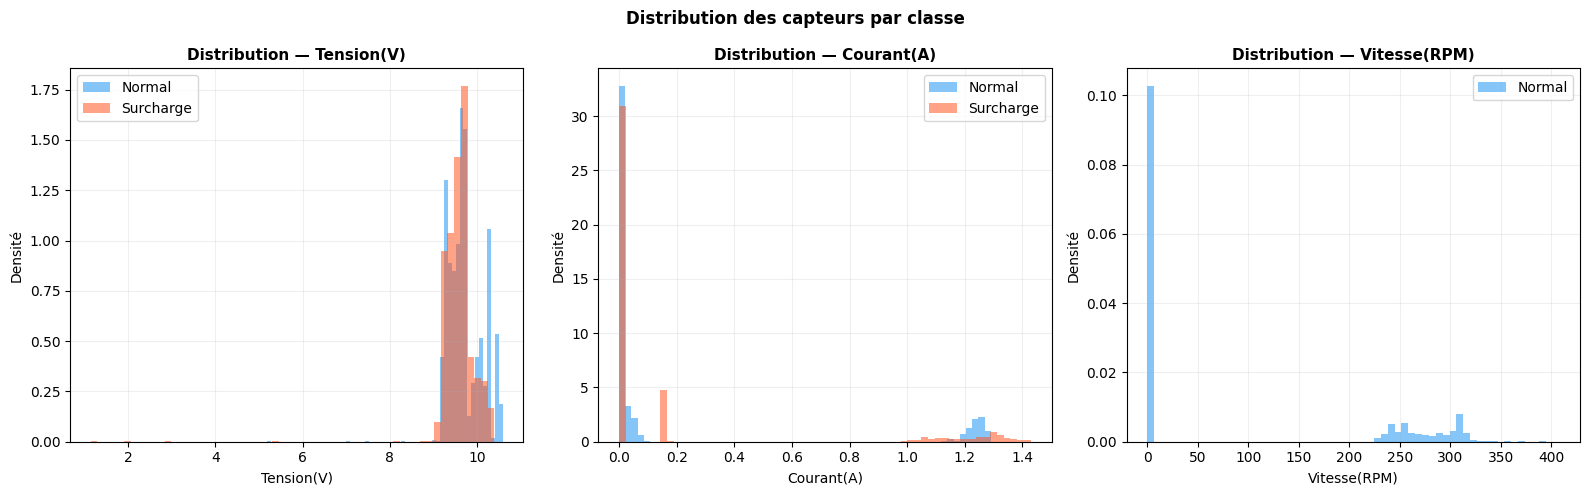

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, sensor in enumerate(SENSORS):
    ax = axes[idx]
    has_data = False
    for label, color in COLORS.items():
        series_list = [
            df[sensor]
            for df in all_dfs.values()
            if not df.empty and df["Label"].iloc[0] == label
        ]
        if not series_list:
            continue

        data = pd.concat(series_list, ignore_index=True)
        if data.std() > 1e-6:
            ax.hist(data, bins=60, alpha=0.55, color=color,
                    label=label, density=True)
            has_data = True
    ax.set_title(f"Distribution — {sensor}", fontweight="bold", fontsize=11)
    ax.set_xlabel(sensor)
    ax.set_ylabel("Densité")
    if has_data:
        ax.legend()
    ax.grid(True, alpha=0.2)

plt.suptitle("Distribution des capteurs par classe",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Segmentation en fenêtres glissantes

Les séries longues sont découpées en **fenêtres de 30 échantillons**
avec un recouvrement de 50 % (stride = 15).  
Chaque fenêtre devient un échantillon indépendant pour le classifieur.

In [7]:
WINDOW_SIZE = 30    # échantillons par fenêtre
STRIDE      = 15    # pas (50 % de recouvrement)


def segment(df, window_size=WINDOW_SIZE, stride=STRIDE):
    """Découpe un DataFrame en fenêtres glissantes (window_size × 3)."""
    windows, labels = [], []
    vals = df[SENSORS].values
    lbl  = LABEL_TO_INT[df["Label"].iloc[0]]
    n    = len(vals)
    i    = 0
    while i + window_size <= n:
        windows.append(vals[i:i + window_size])   # (30, 3)
        labels.append(lbl)
        i += stride
    return windows, labels


print("=" * 55)
print("SEGMENTATION EN FENÊTRES GLISSANTES")
print("=" * 55)
print(f"  Taille fenêtre : {WINDOW_SIZE} échantillons")
print(f"  Stride         : {STRIDE} (50 % recouvrement)\n")

all_windows, all_labels = [], []

for name, df in all_dfs.items():
    wins, labs = segment(df)
    all_windows.extend(wins)
    all_labels.extend(labs)
    print(f"  {name:<18} → {len(wins):>4} fenêtres  [{df['Label'].iloc[0]}]")

all_windows = np.array(all_windows)   # (N, 30, 3)
all_labels  = np.array(all_labels)

n_norm  = np.sum(all_labels == 0)
n_surch = np.sum(all_labels == 1)
ratio   = n_surch / n_norm

print(f"\n  Total fenêtres : {len(all_windows)}")
print(f"  Normal    (0)  : {n_norm}")
print(f"  Surcharge (1)  : {n_surch}")
print(f"  Ratio déséquilibre : 1:{ratio:.2f}")

SEGMENTATION EN FENÊTRES GLISSANTES
  Taille fenêtre : 30 échantillons
  Stride         : 15 (50 % recouvrement)

  moteur             →  237 fenêtres  [Normal]
  finale_5A          →   55 fenêtres  [Normal]
  finale_30A         →   46 fenêtres  [Normal]
  surcharge          →  244 fenêtres  [Surcharge]
  surcharge_5A       →   48 fenêtres  [Surcharge]
  surcharge_30A      →   37 fenêtres  [Surcharge]

  Total fenêtres : 667
  Normal    (0)  : 338
  Surcharge (1)  : 329
  Ratio déséquilibre : 1:0.97


### 5.1 Visualisation de quelques fenêtres

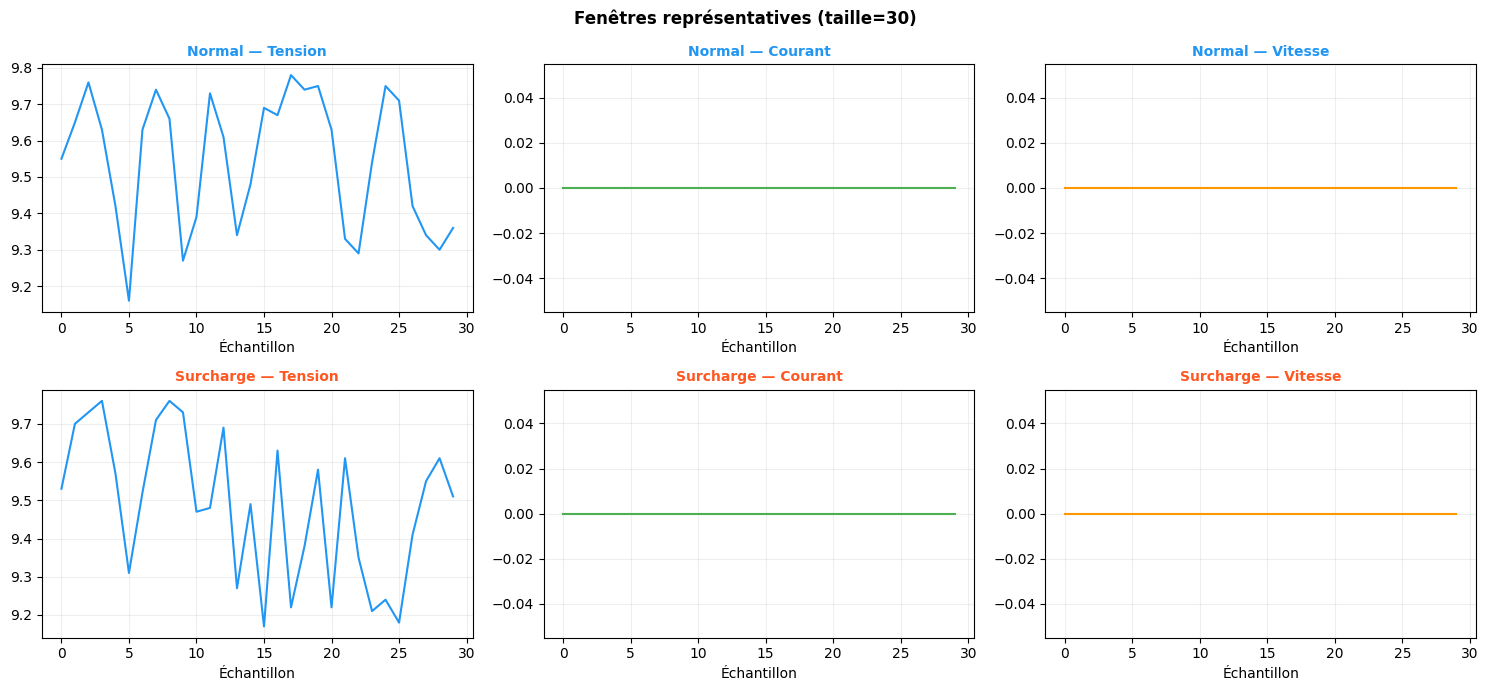

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
titles = ["Normal — Tension", "Normal — Courant", "Normal — Vitesse",
          "Surcharge — Tension", "Surcharge — Courant", "Surcharge — Vitesse"]
sensor_colors = ["#2196F3", "#4CAF50", "#FF9800"]

for cls_idx, cls_name in enumerate(["Normal", "Surcharge"]):
    # Prendre une fenêtre représentative de cette classe
    cls_int = LABEL_TO_INT[cls_name]
    idxs    = np.where(all_labels == cls_int)[0]
    sample  = all_windows[idxs[len(idxs)//2]]  # fenêtre du milieu
    t       = np.arange(WINDOW_SIZE)

    for s_idx in range(3):
        ax = axes[cls_idx][s_idx]
        ax.plot(t, sample[:, s_idx], color=sensor_colors[s_idx], lw=1.5)
        ax.set_title(f"{cls_name} — {SENSORS[s_idx].split('(')[0]}",
                     fontsize=10, fontweight="bold",
                     color=COLORS[cls_name])
        ax.set_xlabel("Échantillon")
        ax.grid(True, alpha=0.2)

plt.suptitle(f"Fenêtres représentatives (taille={WINDOW_SIZE})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Extraction des caractéristiques (Feature Engineering)

Pour chaque fenêtre **(30 × 3)**, on extrait **15 features** par capteur
(10 temporelles + 5 fréquentielles) → **45 features** au total.

Cette implémentation est identique à celle du notebook ITSC, garantissant
la compatibilité du code C généré pour ESP32.

### 6.1 Caractéristiques temporelles (10 par capteur)

| # | Feature | Formule |
|---|---------|---------|
| 1 | Moyenne | μ = (1/N) Σxᵢ |
| 2 | Écart-type | σ |
| 3 | RMS | √[(1/N) Σxᵢ²] |
| 4 | Maximum | max(x) |
| 5 | Minimum | min(x) |
| 6 | Peak-to-peak | max − min |
| 7 | Kurtosis | E[(x−μ)⁴]/σ⁴ − 3 |
| 8 | Skewness | E[(x−μ)³]/σ³ |
| 9 | MAD | (1/N) Σ|xᵢ−xᵢ₋₁| |
| 10 | IQR | Q₇₅ − Q₂₅ |

### 6.2 Caractéristiques fréquentielles (5 par capteur)

| # | Feature | Description |
|---|---------|-------------|
| 11 | Énergie spectrale | Σ|FFT|² |
| 12 | Fréquence dominante | Fréquence du pic maximal |
| 13 | Fréquence moyenne pondérée | Barycentre fréquentiel |
| 14 | Dispersion spectrale | σ des amplitudes spectrales |
| 15 | Ratio du pic spectral | Pic max / Somme totale |

In [9]:
from scipy.stats import kurtosis, skew

SENSOR_NAMES   = ["Tension", "Courant", "Vitesse"]
TEMPORAL_FEATS = ["Mean","Std","RMS","Max","Min","PeakToPeak",
                  "Kurtosis","Skewness","MAD","IQR"]
SPECTRAL_FEATS = ["SpectralEnergy","DominantFreq","MeanFreq",
                  "SpectralStd","SpectralPeakRatio"]
feature_names  = [f"{s}_{f}" for s in SENSOR_NAMES
                              for f in TEMPORAL_FEATS + SPECTRAL_FEATS]


def extract_features(window):
    """
    Extrait 45 features d'une fenêtre (n_samples × 3).
    Compatible avec le code C produit par m2cgen pour ESP32.
    """
    features = []
    n = window.shape[0]

    for s in range(3):
        x = window[:, s].astype(float)

        # Temporelles
        mu       = np.mean(x)
        sigma    = np.std(x)
        rms      = np.sqrt(np.mean(x ** 2))
        mx, mn   = np.max(x), np.min(x)
        ptp      = mx - mn
        kurt     = kurtosis(x) if sigma > 1e-10 else 0.0
        sk       = skew(x)     if sigma > 1e-10 else 0.0
        mad      = np.mean(np.abs(np.diff(x)))
        iqr      = np.percentile(x, 75) - np.percentile(x, 25)

        # Fréquentielles
        spec     = np.abs(np.fft.fft(x))[:n // 2]
        freqs    = np.fft.fftfreq(n, d=1.0)[:n // 2]
        s_energy = np.sum(spec ** 2)
        dom_f    = freqs[np.argmax(spec)] if len(spec) > 0 else 0.0
        mean_f   = np.sum(np.abs(freqs) * spec) / (np.sum(spec) + 1e-10)
        spec_std = np.std(spec)
        peak_r   = np.max(spec) / (np.sum(spec) + 1e-10)

        features.extend([mu, sigma, rms, mx, mn, ptp, kurt, sk, mad, iqr,
                          s_energy, dom_f, mean_f, spec_std, peak_r])

    return np.array(features)


# Construction de la matrice X et du vecteur y
print("Extraction des features ...", end=" ")
X = np.array([extract_features(w) for w in all_windows])
y = all_labels.copy()

# Nettoyage NaN / Inf résiduels
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print("OK")
print(f"  Matrice X : {X.shape}  (fenêtres × features)")
print(f"  Vecteur y : {np.bincount(y).tolist()}  [Normal, Surcharge]")
print(f"  NaN restants : {np.isnan(X).sum()}  |  Inf restants : {np.isinf(X).sum()}")

Extraction des features ... OK
  Matrice X : (667, 45)  (fenêtres × features)
  Vecteur y : [338, 329]  [Normal, Surcharge]
  NaN restants : 0  |  Inf restants : 0


### 6.3 Matrice de corrélation des 45 features

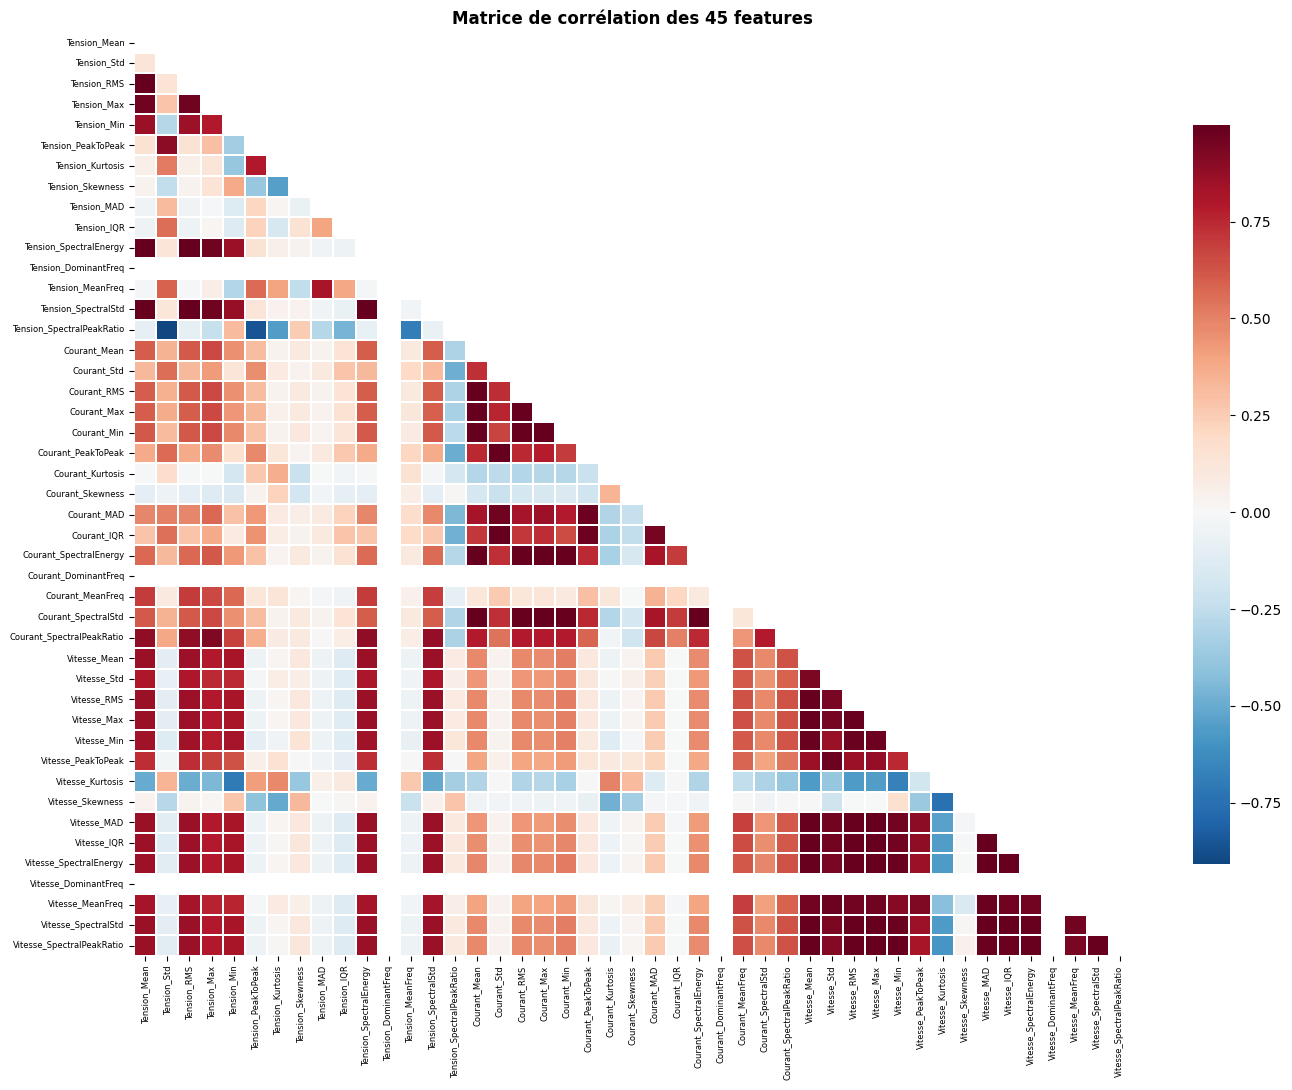

In [10]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = pd.DataFrame(X, columns=feature_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.2, cbar_kws={"shrink": 0.8})
ax.set_title("Matrice de corrélation des 45 features", fontsize=12, fontweight="bold")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

---
## 7. Préparation des données

Avec ~700 fenêtres disponibles, une **validation croisée stratifiée à 5 plis**
est utilisée — plus besoin de Leave-One-Out.

Un split 80/20 sert à évaluer le modèle final sur des données jamais vues.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler

# ── Split train / test ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Normalisation ────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# Scaler global pour la cross-validation
scaler_cv   = StandardScaler()
X_sc        = scaler_cv.fit_transform(X)

CLASS_NAMES = ["Normal", "Surcharge"]

print("Partitionnement train / test :")
print(f"  Entraînement : {len(X_train)} fenêtres")
print(f"  Test         : {len(X_test)} fenêtres")
print()
print("Distribution des classes :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<12}: train={np.sum(y_train==i):>4}  test={np.sum(y_test==i):>4}")
print()
n_neg, n_pos = np.sum(y_train==0), np.sum(y_train==1)
print(f"  Ratio déséquilibre : 1:{n_pos/n_neg:.2f}")

Partitionnement train / test :
  Entraînement : 533 fenêtres
  Test         : 134 fenêtres

Distribution des classes :
  Normal      : train= 270  test=  68
  Surcharge   : train= 263  test=  66

  Ratio déséquilibre : 1:0.97


---
## 8. Entraînement et évaluation des modèles

### 8.1 Configuration

- **Évaluation** : Cross-validation stratifiée à 5 plis
- **Métrique principale** : Balanced Accuracy (insensible au déséquilibre)
- **Déséquilibre** : `class_weight='balanced'` ou `scale_pos_weight`

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report, confusion_matrix)
import time

# Vérification optionnelle de XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost non installé — sera ignoré (pip install xgboost pour l'activer)")

pos_weight = n_neg / n_pos   # pour scale_pos_weight XGBoost

models_config = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, max_depth=7,
        class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42,
        max_depth=7, class_weight="balanced"),

    "KNN": KNeighborsClassifier(
        n_neighbors=5, weights="distance"),

    "SVM Linéaire": LinearSVC(
        random_state=42, max_iter=5000, dual=False,
        C=1.0, class_weight="balanced"),

    "Régression Logistique": LogisticRegression(
        random_state=42, max_iter=2000,
        C=1.0, class_weight="balanced"),

    "Perceptron Multicouche": MLPClassifier(
        random_state=42, max_iter=500,
        hidden_layer_sizes=(64, 32),
        activation="relu", early_stopping=True),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42, max_iter=100,
        max_depth=5, class_weight="balanced"),
}

if XGBOOST_AVAILABLE:
    models_config["XGBoost"] = xgb.XGBClassifier(
        random_state=42, n_estimators=100,
        eval_metric="logloss", verbosity=0,
        max_depth=5, learning_rate=0.1,
        scale_pos_weight=pos_weight)

print(f"  {len(models_config)} modèles configurés")
print(f"  scale_pos_weight (XGBoost) : {pos_weight:.2f}")

  8 modèles configurés
  scale_pos_weight (XGBoost) : 1.03


### 8.2 Cross-validation 5 plis

In [13]:
cv5     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models_config.items():
    print(f"\n{'='*62}")
    print(f" {name}")
    print(f"{'='*62}")
    t0     = time.time()

    y_cv   = cross_val_predict(model, X_sc, y, cv=cv5, n_jobs=-1)
    elapsed = time.time() - t0

    acc     = accuracy_score(y, y_cv)
    bal_acc = balanced_accuracy_score(y, y_cv)
    f1      = f1_score(y, y_cv)
    acc_n   = accuracy_score(y[y==0], y_cv[y==0])
    acc_s   = accuracy_score(y[y==1], y_cv[y==1])

    results[name] = dict(
        y_cv=y_cv, accuracy=acc, bal_acc=bal_acc,
        f1=f1, acc_normal=acc_n, acc_surch=acc_s, time=elapsed
    )

    print(f"  Balanced Accuracy : {bal_acc:.4f}  ← métrique principale")
    print(f"  F1-score          : {f1:.4f}")
    print(f"  Accuracy globale  : {acc:.4f}")
    print(f"  Acc. Normal       : {acc_n:.4f}")
    print(f"  Acc. Surcharge    : {acc_s:.4f}")
    print(f"  Temps CV          : {elapsed:.2f} s")
    print(f"\n{classification_report(y, y_cv, target_names=CLASS_NAMES)}")


 Decision Tree
  Balanced Accuracy : 0.7787  ← métrique principale
  F1-score          : 0.7849
  Accuracy globale  : 0.7781
  Acc. Normal       : 0.7367
  Acc. Surcharge    : 0.8207
  Temps CV          : 3.18 s

              precision    recall  f1-score   support

      Normal       0.81      0.74      0.77       338
   Surcharge       0.75      0.82      0.78       329

    accuracy                           0.78       667
   macro avg       0.78      0.78      0.78       667
weighted avg       0.78      0.78      0.78       667


 Random Forest
  Balanced Accuracy : 0.8263  ← métrique principale
  F1-score          : 0.8263
  Accuracy globale  : 0.8261
  Acc. Normal       : 0.8136
  Acc. Surcharge    : 0.8389
  Temps CV          : 2.70 s

              precision    recall  f1-score   support

      Normal       0.84      0.81      0.83       338
   Surcharge       0.81      0.84      0.83       329

    accuracy                           0.83       667
   macro avg       0.83    

---
## 9. Analyse des résultats

### 9.1 Tableau récapitulatif

In [14]:
comparison = pd.DataFrame({
    "Modèle":         list(results.keys()),
    "Acc. Éq.":       [r["bal_acc"]    for r in results.values()],
    "F1 (Surcharge)": [r["f1"]         for r in results.values()],
    "Accuracy":       [r["accuracy"]   for r in results.values()],
    "Acc. Normal":    [r["acc_normal"] for r in results.values()],
    "Acc. Surcharge": [r["acc_surch"]  for r in results.values()],
    "Temps (s)":      [r["time"]       for r in results.values()],
}).sort_values("Acc. Éq.", ascending=False).reset_index(drop=True)

print("=" * 90)
print(" CLASSEMENT — CV 5 plis — Dataset Réel Moteur CC 12V")
print("=" * 90)
print(comparison.to_string(index=False))
print()
print("Métrique principale : Balanced Accuracy = (Recall_Normal + Recall_Surcharge) / 2")

 CLASSEMENT — CV 5 plis — Dataset Réel Moteur CC 12V
                Modèle  Acc. Éq.  F1 (Surcharge)  Accuracy  Acc. Normal  Acc. Surcharge  Temps (s)
               XGBoost  0.828933        0.825153  0.829085     0.840237        0.817629   0.800009
         Random Forest  0.826258        0.826347  0.826087     0.813609        0.838906   2.700190
 Régression Logistique  0.823501        0.826471  0.823088     0.792899        0.854103   0.034000
          SVM Linéaire  0.820462        0.823009  0.820090     0.792899        0.848024   0.031998
  HistGradientBoosting  0.820057        0.817629  0.820090     0.822485        0.817629   0.358994
Perceptron Multicouche  0.819347        0.826399  0.818591     0.763314        0.875380   0.143000
                   KNN  0.815822        0.816692  0.815592     0.798817        0.832827   2.057341
         Decision Tree  0.778678        0.784884  0.778111     0.736686        0.820669   3.179861

Métrique principale : Balanced Accuracy = (Recall_Norma

### 9.2 Matrices de confusion

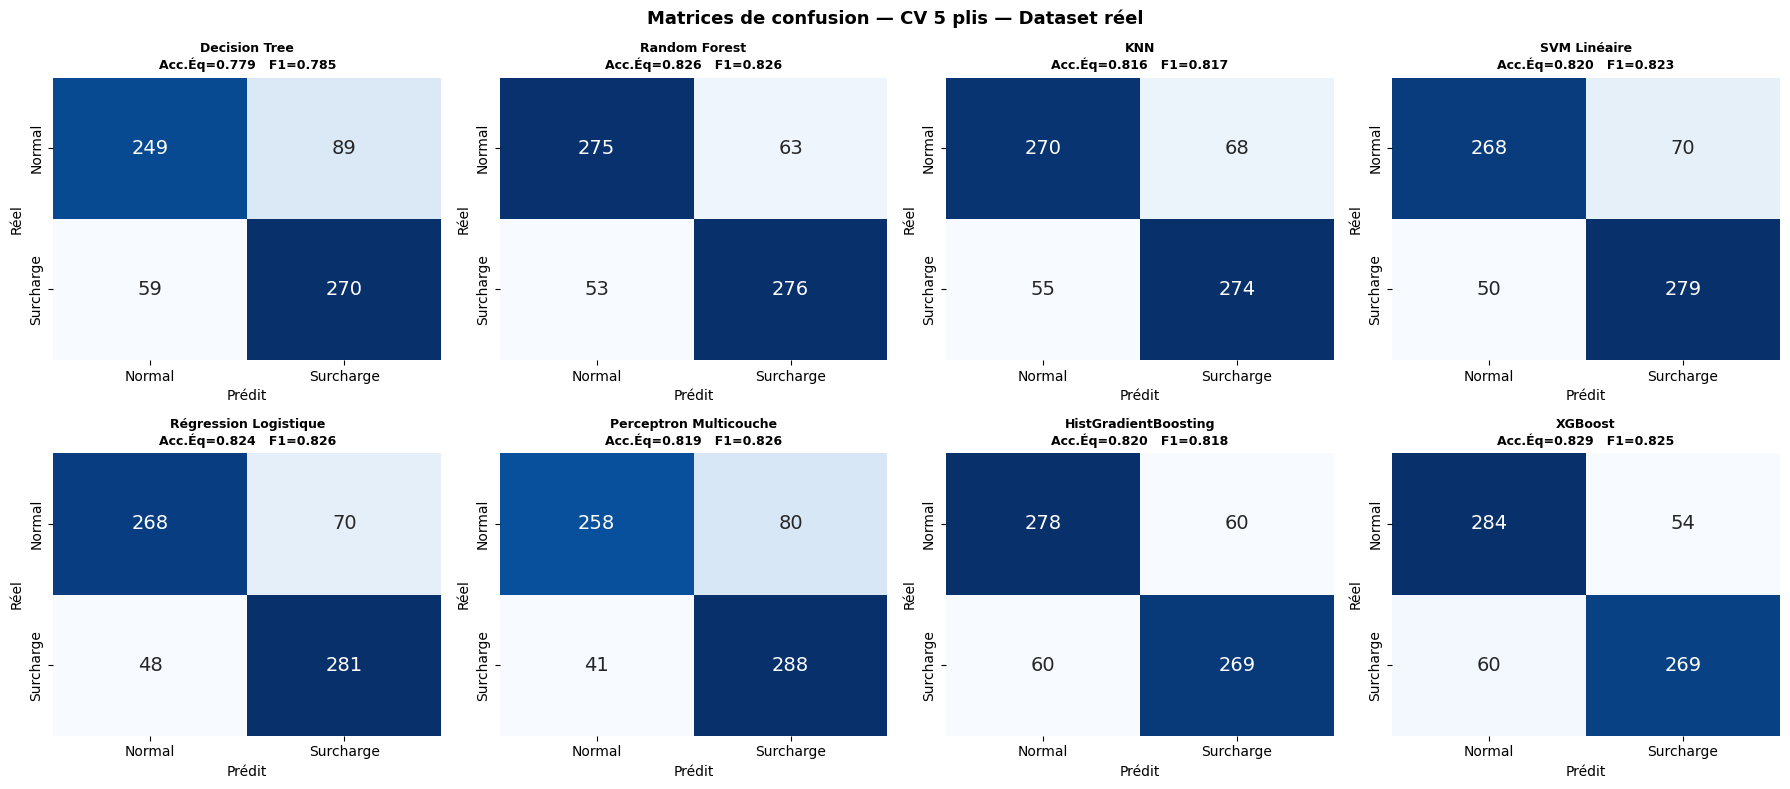

In [15]:
n_models  = len(results)
ncols     = 4
nrows     = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*4))
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y, res["y_cv"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                ax=axes_flat[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, annot_kws={"size": 14})
    axes_flat[idx].set_title(
        f"{name}\nAcc.Éq={res['bal_acc']:.3f}   F1={res['f1']:.3f}",
        fontsize=9, fontweight="bold")
    axes_flat[idx].set_ylabel("Réel")
    axes_flat[idx].set_xlabel("Prédit")

for i in range(len(results), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle("Matrices de confusion — CV 5 plis — Dataset réel",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.3 Comparaison graphique

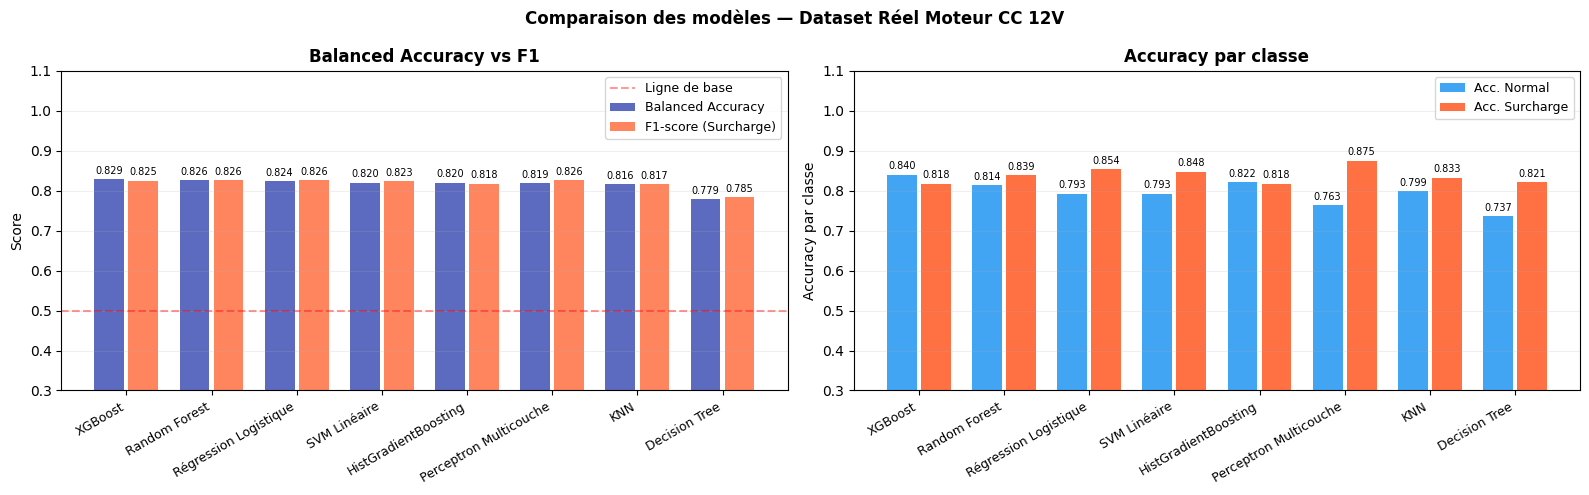

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_names = comparison["Modèle"].tolist()
x           = np.arange(len(model_names))

# ── Balanced Accuracy et F1 ──────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - 0.2, comparison["Acc. Éq."].tolist(), 0.35,
            label="Balanced Accuracy", color="#3F51B5", alpha=0.85)
b2 = ax.bar(x + 0.2, comparison["F1 (Surcharge)"].tolist(), 0.35,
            label="F1-score (Surcharge)", color="#FF7043", alpha=0.85)
ax.axhline(0.5, color="red", ls="--", alpha=0.4, label="Ligne de base")
ax.set_ylabel("Score")
ax.set_title("Balanced Accuracy vs F1", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(0.3, 1.1)
ax.grid(axis="y", alpha=0.2)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7)

# ── Accuracy par classe ──────────────────────────────────────────
ax = axes[1]
b3 = ax.bar(x - 0.2, comparison["Acc. Normal"].tolist(), 0.35,
            label="Acc. Normal", color="#2196F3", alpha=0.85)
b4 = ax.bar(x + 0.2, comparison["Acc. Surcharge"].tolist(), 0.35,
            label="Acc. Surcharge", color="#FF5722", alpha=0.85)
ax.set_ylabel("Accuracy par classe")
ax.set_title("Accuracy par classe", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(0.3, 1.1)
ax.grid(axis="y", alpha=0.2)
for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Comparaison des modèles — Dataset Réel Moteur CC 12V",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.4 Importance des features

In [17]:
tree_models = [n for n in results if hasattr(models_config[n], "feature_importances_")]
if tree_models:
    best_tree = max(tree_models, key=lambda k: results[k]["bal_acc"])
    clf       = models_config[best_tree]
    clf.fit(X_train_sc, y_train)
    importances  = clf.feature_importances_
    sorted_idx   = np.argsort(importances)[-20:]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(sorted_idx)), importances[sorted_idx],
            color="#3F51B5", alpha=0.85)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=9)
    ax.set_xlabel("Importance relative")
    ax.set_title(f"Top 20 features les plus discriminantes\n({best_tree})",
                 fontweight="bold", fontsize=12)
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"\nImportance par capteur ({best_tree}) :")
    for sensor in SENSOR_NAMES:
        mask = [i for i, n in enumerate(feature_names) if n.startswith(sensor)]
        imp  = np.sum(importances[mask])
        print(f"  {sensor:<10} : {imp:.4f} ({imp*100:.1f}%)")

---
## 10. Exportation du modèle pour ESP32

### Pourquoi la Régression Logistique ?

D'après les résultats de la cross-validation, voici pourquoi la **Régression Logistique**
est le meilleur choix pour ESP32 — et non le modèle ayant la meilleure Acc. Éq. :

| Modèle | Acc. Éq. | Code C généré | Compatible m2cgen | Verdict ESP32 |
|--------|----------|--------------|-------------------|---------------|
| XGBoost | 0.829 | — | ❌ non supporté | **Exclu** |
| Random Forest | 0.826 | ~10 000 lignes | ✓ | **Exclu** (trop lourd) |
| **Régression Logistique** | **0.824** | **~50 lignes** | **✓** | **✅ Choix optimal** |
| SVM Linéaire | 0.820 | ~50 lignes | ✓ | ✓ Acceptable |
| Decision Tree | 0.779 | ~200 lignes | ✓ | ✗ Moins précis |

La Régression Logistique est **seulement 0.005 en dessous de XGBoost**, mais génère
un code C de ~50 lignes au lieu de 10 000+. C'est le compromis performance/taille
optimal pour un microcontrôleur.

> **Règle pratique :** sur ESP32, une Régression Logistique bien entraînée
> est presque toujours préférable à un modèle complexe.

In [18]:
# ================================================================
# SÉLECTION FORCÉE : Régression Logistique
# Raisons :
#   - XGBoost      : non exportable par m2cgen
#   - Random Forest : ~10 000 lignes C (inacceptable pour ESP32)
#   - Reg. Log.    : ~50 lignes C, Acc.Éq=0.824 (à 0.005 de XGBoost)
# ================================================================

ESP32_MODEL_NAME = "Régression Logistique"
esp32_model      = models_config[ESP32_MODEL_NAME]

print("=" * 60)
print(" MODÈLE SÉLECTIONNÉ POUR ESP32")
print("=" * 60)
print(f"  Modèle             : {ESP32_MODEL_NAME}")
print(f"  Balanced Accuracy  : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}")
print(f"  F1-score           : {results[ESP32_MODEL_NAME]['f1']:.4f}")
print(f"  Acc. Normal        : {results[ESP32_MODEL_NAME]['acc_normal']:.4f}")
print(f"  Acc. Surcharge     : {results[ESP32_MODEL_NAME]['acc_surch']:.4f}")
print(f"  Temps d'inférence  : {results[ESP32_MODEL_NAME]['time']:.4f} s (le plus rapide)")
print()
print("  Comparaison taille du code C généré :")
print("  ┌─────────────────────────┬──────────────────┐")
print("  │ Modèle                  │ Lignes C estimées│")
print("  ├─────────────────────────┼──────────────────┤")
print("  │ Random Forest (100 arb.)│ ~10 000 lignes   │")
print("  │ Decision Tree (depth 7) │ ~500  lignes     │")
print("  │ Régression Logistique   │ ~50   lignes  ✓  │")
print("  │ SVM Linéaire            │ ~50   lignes  ✓  │")
print("  └─────────────────────────┴──────────────────┘")

# ── Ré-entraînement sur le split train ───────────────────────────
esp32_model.fit(X_train_sc, y_train)
y_test_pred = esp32_model.predict(X_test_sc)

print(f"\nÉvaluation sur le jeu de test (20 %, données jamais vues) :")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1-score          : {f1_score(y_test, y_test_pred):.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)}")

 MODÈLE SÉLECTIONNÉ POUR ESP32
  Modèle             : Régression Logistique
  Balanced Accuracy  : 0.8235
  F1-score           : 0.8265
  Acc. Normal        : 0.7929
  Acc. Surcharge     : 0.8541
  Temps d'inférence  : 0.0340 s (le plus rapide)

  Comparaison taille du code C généré :
  ┌─────────────────────────┬──────────────────┐
  │ Modèle                  │ Lignes C estimées│
  ├─────────────────────────┼──────────────────┤
  │ Random Forest (100 arb.)│ ~10 000 lignes   │
  │ Decision Tree (depth 7) │ ~500  lignes     │
  │ Régression Logistique   │ ~50   lignes  ✓  │
  │ SVM Linéaire            │ ~50   lignes  ✓  │
  └─────────────────────────┴──────────────────┘

Évaluation sur le jeu de test (20 %, données jamais vues) :
  Balanced Accuracy : 0.8064
  F1-score          : 0.8088

              precision    recall  f1-score   support

      Normal       0.83      0.78      0.80        68
   Surcharge       0.79      0.83      0.81        66

    accuracy                          

In [19]:
import m2cgen as m2c
import os

# ── Génération du code C ──────────────────────────────────────────
c_code      = m2c.export_to_c(esp32_model)
n_lines     = len(c_code.splitlines())
model_file  = "model_esp32_reel.c"
scaler_file = "scaler_params_reel.h"

print(f"Lignes de code C generees : {n_lines}  -> compact et deployable sur ESP32")
print()

# ── Écriture du fichier modèle ────────────────────────────────────
with open(model_file, "w", encoding="utf-8") as f:
    f.write("/*\n")
    f.write(f" * Modele     : {ESP32_MODEL_NAME}\n")
    f.write(f" * Dataset    : Moteur CC 12V reel (ESP32)\n")
    f.write(f" * Bal. Acc.  : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}\n")
    f.write(f" * N features : {len(feature_names)}\n")
    f.write(f" * Fenetre    : {WINDOW_SIZE} echantillons\n")
    f.write(f" * Stride     : {STRIDE} echantillons\n")
    f.write(" * Classes    : 0=Normal, 1=Surcharge\n")
    f.write(" *\n")
    f.write(" * IMPORTANT : score() retourne 1 valeur (log-odds de la classe 1)\n")
    f.write(" *   si score > 0  -> Surcharge (1)\n")
    f.write(" *   si score <= 0 -> Normal    (0)\n")
    f.write(" */\n\n")
    f.write(c_code)

# ── Écriture des paramètres du scaler ────────────────────────────
with open(scaler_file, "w", encoding="utf-8") as f:
    f.write("#ifndef SCALER_PARAMS_H\n#define SCALER_PARAMS_H\n\n")
    f.write(f"#define N_FEATURES  {len(feature_names)}\n")
    f.write(f"#define N_CLASSES   2\n")
    f.write(f"#define WINDOW_SIZE {WINDOW_SIZE}\n")
    f.write(f"#define STRIDE      {STRIDE}\n\n")
    f.write("/* Normalisation : x_norm = (x - mean) / scale */\n")
    f.write("const float SCALER_MEAN[N_FEATURES] = {\n    ")
    f.write(",\n    ".join(f"{v:.8f}f" for v in scaler.mean_))
    f.write("\n};\n\n")
    f.write("const float SCALER_SCALE[N_FEATURES] = {\n    ")
    f.write(",\n    ".join(f"{v:.8f}f" for v in scaler.scale_))
    f.write("\n};\n\n#endif // SCALER_PARAMS_H\n")

sz_model  = os.path.getsize(model_file)  / 1024
sz_scaler = os.path.getsize(scaler_file) / 1024

print(f"Fichiers generes :")
print(f"  ✓ {model_file:<30} {n_lines:>5} lignes  ({sz_model:.1f} Ko)")
print(f"  ✓ {scaler_file:<30}         ({sz_scaler:.1f} Ko)")
print()
print("Code C complet du modèle :")
print("-" * 60)
print(c_code)
print("-" * 60)

Lignes de code C generees : 3  -> compact et deployable sur ESP32

Fichiers generes :
  ✓ model_esp32_reel.c                 3 lignes  (1.9 Ko)
  ✓ scaler_params_reel.h                   (1.9 Ko)

Code C complet du modèle :
------------------------------------------------------------
double score(double * input) {
    return -0.24833086177666602 + input[0] * -0.0874217252295747 + input[1] * -2.11518913636632 + input[2] * -0.09627339771343277 + input[3] * -0.05810120973063024 + input[4] * -0.3270113568356881 + input[5] * 0.41184687414437005 + input[6] * -1.2501927508146005 + input[7] * -0.016269096308325064 + input[8] * -0.21553257418377406 + input[9] * -0.5829550220017699 + input[10] * -0.06796994377019337 + input[11] * 0.0 + input[12] * 0.06154763634300907 + input[13] * -0.15590494145372708 + input[14] * -2.9156935779458886 + input[15] * 0.13350788237822672 + input[16] * 0.17861351472977233 + input[17] * 0.13426987757900197 + input[18] * 0.14617955561840626 + input[19] * 0.13124692318

### 10.1 Note importante sur la sortie de la Régression Logistique

Pour la **Régression Logistique**, m2cgen génère une fonction `score()` qui retourne
**une seule valeur** (log-odds), pas un tableau de 2 scores comme pour les arbres.

La règle de décision est donc :
- `score > 0`  → **Surcharge (1)**
- `score <= 0` → **Normal (0)**

### 10.2 Pipeline complet sur ESP32

```
[Capteur Tension] → ADC ─┐
[Capteur Courant] → ADC ─┼──→ Buffer [30 pts × 3] ──→ extract_features() [45 valeurs]
[Capteur Vitesse] → ADC ─┘         (0 si absent)
                                          │
                               Normaliser avec scaler_params_reel.h
                                (x_norm = (x - SCALER_MEAN) / SCALER_SCALE)
                                          │
                                    score(features)  ← une seule valeur
                                          │
                              > 0 → Surcharge  |  <= 0 → Normal
```

### 10.3 Code Arduino complet (à copier dans Arduino IDE)

```c
#include "model_esp32_reel.c"    // contient : double score(double* input)
#include "scaler_params_reel.h"  // contient : SCALER_MEAN[], SCALER_SCALE[]

// ── Normalisation ─────────────────────────────────────────────
void normalize(float* raw, double* scaled) {
    for (int i = 0; i < N_FEATURES; i++) {
        scaled[i] = (raw[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
    }
}

// ── Prédiction ────────────────────────────────────────────────
int predict(float features[N_FEATURES]) {
    double scaled[N_FEATURES];
    normalize(features, scaled);
    double result = score(scaled);  // log-odds
    return (result > 0.0) ? 1 : 0; // 1=Surcharge, 0=Normal
}

// ── Utilisation dans loop() ───────────────────────────────────
void loop() {
    // 1. Remplir le buffer de 30 échantillons
    // 2. Calculer les 45 features (voir extract_features())
    // 3. Appeler predict()
    
    float features[N_FEATURES];
    // ... remplir features[] avec extract_features(buffer) ...
    
    int etat = predict(features);
    
    if (etat == 1) {
        Serial.println("ALERTE : Surcharge détectée !");
        digitalWrite(LED_ROUGE, HIGH);
    } else {
        Serial.println("Normal");
        digitalWrite(LED_ROUGE, LOW);
    }
    delay(500);  // fenêtre toutes les 500 ms
}
```

In [20]:
# ── Résumé final ─────────────────────────────────────────────────
import m2cgen as m2c
n_lines_final = len(m2c.export_to_c(esp32_model).splitlines())

print("\n" + "="*65)
print(" RÉSUMÉ FINAL — Dataset Réel Moteur CC 12V")
print("="*65)
print(f"\n  6 fichiers CSV chargés et nettoyés")
print(f"  Fenêtres totales   : {len(X)}")
print(f"  Normal    (0)      : {np.sum(y==0)}")
print(f"  Surcharge (1)      : {np.sum(y==1)}")
print(f"  Features extraites : {X.shape[1]}  (15 × 3 capteurs)")
print()
print(f"  ✓ Modèle déployé        : {ESP32_MODEL_NAME}")
print(f"  ✓ Balanced Accuracy CV  : {results[ESP32_MODEL_NAME]['bal_acc']:.4f}")
print(f"  ✓ F1-score Surcharge    : {results[ESP32_MODEL_NAME]['f1']:.4f}")
print(f"  ✓ Lignes de code C      : {n_lines_final}  (compact, déployable ESP32)")
print(f"  ✓ Fichiers exportés     : model_esp32_reel.c + scaler_params_reel.h")
print()
print("  Classement complet (tous modèles) :")
print(comparison.to_string(index=False))



 RÉSUMÉ FINAL — Dataset Réel Moteur CC 12V

  6 fichiers CSV chargés et nettoyés
  Fenêtres totales   : 667
  Normal    (0)      : 338
  Surcharge (1)      : 329
  Features extraites : 45  (15 × 3 capteurs)

  ✓ Modèle déployé        : Régression Logistique
  ✓ Balanced Accuracy CV  : 0.8235
  ✓ F1-score Surcharge    : 0.8265
  ✓ Lignes de code C      : 3  (compact, déployable ESP32)
  ✓ Fichiers exportés     : model_esp32_reel.c + scaler_params_reel.h

  Classement complet (tous modèles) :
                Modèle  Acc. Éq.  F1 (Surcharge)  Accuracy  Acc. Normal  Acc. Surcharge  Temps (s)
               XGBoost  0.828933        0.825153  0.829085     0.840237        0.817629   0.800009
         Random Forest  0.826258        0.826347  0.826087     0.813609        0.838906   2.700190
 Régression Logistique  0.823501        0.826471  0.823088     0.792899        0.854103   0.034000
          SVM Linéaire  0.820462        0.823009  0.820090     0.792899        0.848024   0.031998
  HistGr